In [ ]:
%pip install puremacro


# Real-Time Data, Historical Vintages & The Mankiw-Shapiro Test

**How do data revisions affect macroeconomic analysis, and how can we tell whether a first statistical release is an efficient forecast of the final figure ("news") or the final figure plus measurement error ("noise")?**

**The vintage panel in this notebook is simulated, and the process that generates it is known: pure noise.** The country and variable names are labels only. Nothing is downloaded, and no number below describes the United States, Germany, the United Kingdom or Mexico.

Macroeconomic aggregates like GDP, consumption and investment are revised for years as statistical agencies incorporate administrative data, benchmark surveys and methodological updates:

1. **Real-time information and policy errors.** Orphanides (2001, *American Economic Review*) showed that the policy mistakes of the 1970s partly reflected output-gap estimates made on real-time data that were later heavily revised. Croushore & Stark (2001, *Journal of Econometrics*) built the real-time data set that made such analysis routine.

2. **The Mankiw & Shapiro (1986) news-versus-noise test.** Let $y_{0,t}$ be the first release of growth in quarter $t$ and $y_{T,t}$ the final, revised figure. The revision is
   $$ r_t = y_{T,t} - y_{0,t} $$
   Mankiw & Shapiro (1986, *Survey of Current Business*; NBER Working Paper 1939) regress the revision on each release:
   $$ r_t = \alpha_0 + \beta_0 \, y_{0,t} + \varepsilon_t, \qquad r_t = \alpha_T + \beta_T \, y_{T,t} + \eta_t $$

   - **News** ($\beta_0 = 0$): the first release is an efficient forecast, $y_{0,t} = \mathbb{E}[y_{T,t} \mid \Omega_t]$, so the revision is new information, uncorrelated with what was published.
   - **Noise** ($\beta_T = 0$): the first release is the final figure plus classical measurement error, $y_{0,t} = y_{T,t} + v_t$ with $\text{Cov}(y_{T,t}, v_t) = 0$. The revision $r_t = -v_t$ is then uncorrelated with the final figure but negatively correlated with the first release, with slope $\beta_0 = -\text{Var}(v)/\text{Var}(y_0)$. That slope lies between $-1$ and $0$; it approaches $-1$ only when the noise dominates the variance of the first release.

We inspect `puremacro`'s catalogue of real-time series, build a simulated panel of vintages, draw revision triangles, run both regressions with `QNAVintagePanel.revision_stats` (which delegates them to `puremacro.vintages.mankiw_shapiro`), and slice point-in-time data sets with `puremacro.fetch.QNAVintagePanel`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch import (
    get_qna_vintage_catalog,
    QNAVintagePanel,
)
from puremacro.vintages import mankiw_shapiro

## 1. The QNA Vintage Catalogue

Real-time research needs each observation as it was published on a given date. Archives such as the Federal Reserve Bank of St. Louis ALFRED (ArchivaL Federal Reserve Economic Data) store every series together with its publication dates (vintages).

`get_qna_vintage_catalog()` lists the series identifiers that `puremacro`'s real-time fetchers would request: one row per country and national-accounts variable, with identifiers built from the naming pattern of the OECD Main Economic Indicators on FRED (the United States uses its own FRED series). The catalogue is a table in the library; calling it downloads nothing, and whether ALFRED holds vintages for a given identifier is only known when you fetch it.

In [2]:
catalog = get_qna_vintage_catalog()
print(f"Catalogue: {len(catalog)} series, {catalog['country'].nunique()} countries, {catalog['variable'].nunique()} variables")
print("\nSample of catalogue entries:")
print(catalog[["country", "country_name", "region", "variable", "series_id"]].head(10).to_string(index=False))

# Summary by variable
var_counts = catalog.groupby("variable")["country"].count().reset_index()
var_counts.columns = ["Variable", "Country Count"]
print("\nVariable coverage across countries:")
print(var_counts.to_string(index=False))

Catalogue: 360 series, 45 countries, 8 variables

Sample of catalogue entries:
country country_name           region     variable       series_id
    AUS    Australia OECD_AsiaPacific     con_real NAEXKP02AUQ652S
    AUS    Australia OECD_AsiaPacific     deflator CPALTT01AUQ659N
    AUS    Australia OECD_AsiaPacific exports_real NAEXKP06AUQ652S
    AUS    Australia OECD_AsiaPacific      gdp_nom NAEXCP01AUQ652S
    AUS    Australia OECD_AsiaPacific     gdp_real NAEXKP01AUQ652S
    AUS    Australia OECD_AsiaPacific    gfcf_real NAEXKP04AUQ652S
    AUS    Australia OECD_AsiaPacific  govcon_real NAEXKP03AUQ652S
    AUS    Australia OECD_AsiaPacific imports_real NAEXKP07AUQ652S
    AUT      Austria      OECD_Europe     con_real NAEXKP02ATQ652S
    AUT      Austria      OECD_Europe     deflator CPALTT01ATQ659N

Variable coverage across countries:
    Variable  Country Count
    con_real             45
    deflator             45
exports_real             45
     gdp_nom             45
    gdp

## 2. A Simulated Real-Time Vintage Panel

We simulate 40 reference quarters ($T = 40$) and 50 quarterly publication vintages ($V = 50$) for four country labels and two variables. Let $y_t^*$ be the true growth rate in quarter $t$, drawn independently with mean $2.2$ and standard deviation $\sigma_* = 1.5$. The first release is published one quarter later and contains classical measurement error $v_t \sim \mathcal{N}(0, \sigma_v^2)$, $\sigma_v = 0.6$, independent of $y_t^*$:

$$ y_{0, t} = y_t^* + v_t $$

Each later vintage $j \ge 1$ removes part of the error:

$$ y_{j, t} = y_t^* + e^{-j / \kappa} \, v_t, \qquad \kappa = 3 $$

This is a **pure-noise** process: there is no news, because every revision only removes error. After the 49 vintages available for the first quarter, the remaining error is negligible; the most recent quarter has had 9 revisions and keeps $e^{-3} \approx 5\%$ of its error. Section 5 uses this known truth to grade the tests.

In [3]:
n_quarters = 40
obs_dates = pd.date_range("2010-01-01", periods=n_quarters, freq="QS")
vintage_dates = pd.date_range("2010-04-01", periods=50, freq="QS")
countries = ["USA", "DEU", "GBR", "MEX"]   # labels only: every series is simulated
variables = ["gdp_real", "gfcf_real"]
mean_growth, sd_true, sd_noise, kappa_decay = 2.2, 1.5, 0.6, 3.0

def simulate_vintages(sd_v=sd_noise, dgp="noise", seed=1986):
    """Simulated vintages for every country label and variable.

    dgp="noise": y_0 = y* + v and each vintage removes part of v (classical measurement error).
    dgp="news" : y_0 = y* is the efficient first estimate and each vintage adds part of the news v.
    """
    rng = np.random.default_rng(seed)
    records = []
    for c in countries:
        for var in variables:
            y_star = rng.normal(loc=mean_growth, scale=sd_true, size=n_quarters)
            v = rng.normal(loc=0.0, scale=sd_v, size=n_quarters)
            for i, obs in enumerate(obs_dates):
                for j, vint in enumerate(vintage_dates):
                    if j >= i + 1:   # first published one quarter after the reference quarter
                        decay = np.exp(-(j - i - 1) / kappa_decay)
                        if dgp == "noise":
                            val = y_star[i] + decay * v[i]
                        else:
                            val = y_star[i] + (1.0 - decay) * v[i]
                        records.append({"country": c, "variable": var, "date": obs, "vintage": vint, "value": float(val)})
    return QNAVintagePanel(df=pd.DataFrame(records))

panel = simulate_vintages()
print(f"Simulated QNAVintagePanel: {len(panel.df):,} records, {len(countries)} country labels x {len(variables)} variables")

Simulated QNAVintagePanel: 9,440 records, 4 country labels x 2 variables


## 3. Visualizing the $(T \times V)$ Revision Triangle

Vintage data are usually stored as a triangular revision matrix $\mathbf{R} \in \mathbb{R}^{T \times V}$:

$$ \mathbf{R} = \begin{bmatrix} y_{1, v_1} & y_{1, v_2} & y_{1, v_3} & \dots & y_{1, v_V} \\ \text{NaN} & y_{2, v_2} & y_{2, v_3} & \dots & y_{2, v_V} \\ \text{NaN} & \text{NaN} & y_{3, v_3} & \dots & y_{3, v_V} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ \text{NaN} & \text{NaN} & \text{NaN} & \dots & y_{T, v_V} \end{bmatrix} $$

Each row is a reference quarter $t$ and each column a publication vintage $v$. The leading diagonal holds the first release of each quarter; reading along a row traces how the estimate of that quarter was revised.

In [4]:
tri_usa = panel.revision_matrix("USA", "gdp_real")
print("Simulated 'USA gdp_real' revision matrix (first 6 quarters x 6 vintages):")
print(tri_usa.iloc[:6, :6].round(3).to_string())

Simulated 'USA gdp_real' revision matrix (first 6 quarters x 6 vintages):
vintage     2010-07-01  2010-10-01  2011-01-01  2011-04-01  2011-07-01  2011-10-01
date                                                                              
2010-01-01       0.024       0.267       0.441       0.566       0.655       0.719
2010-04-01         NaN       1.213       1.255       1.285       1.307       1.323
2010-07-01         NaN         NaN       3.968       3.845       3.756       3.693
2010-10-01         NaN         NaN         NaN       1.799       1.832       1.855
2011-01-01         NaN         NaN         NaN         NaN       1.895       2.241
2011-04-01         NaN         NaN         NaN         NaN         NaN       4.008


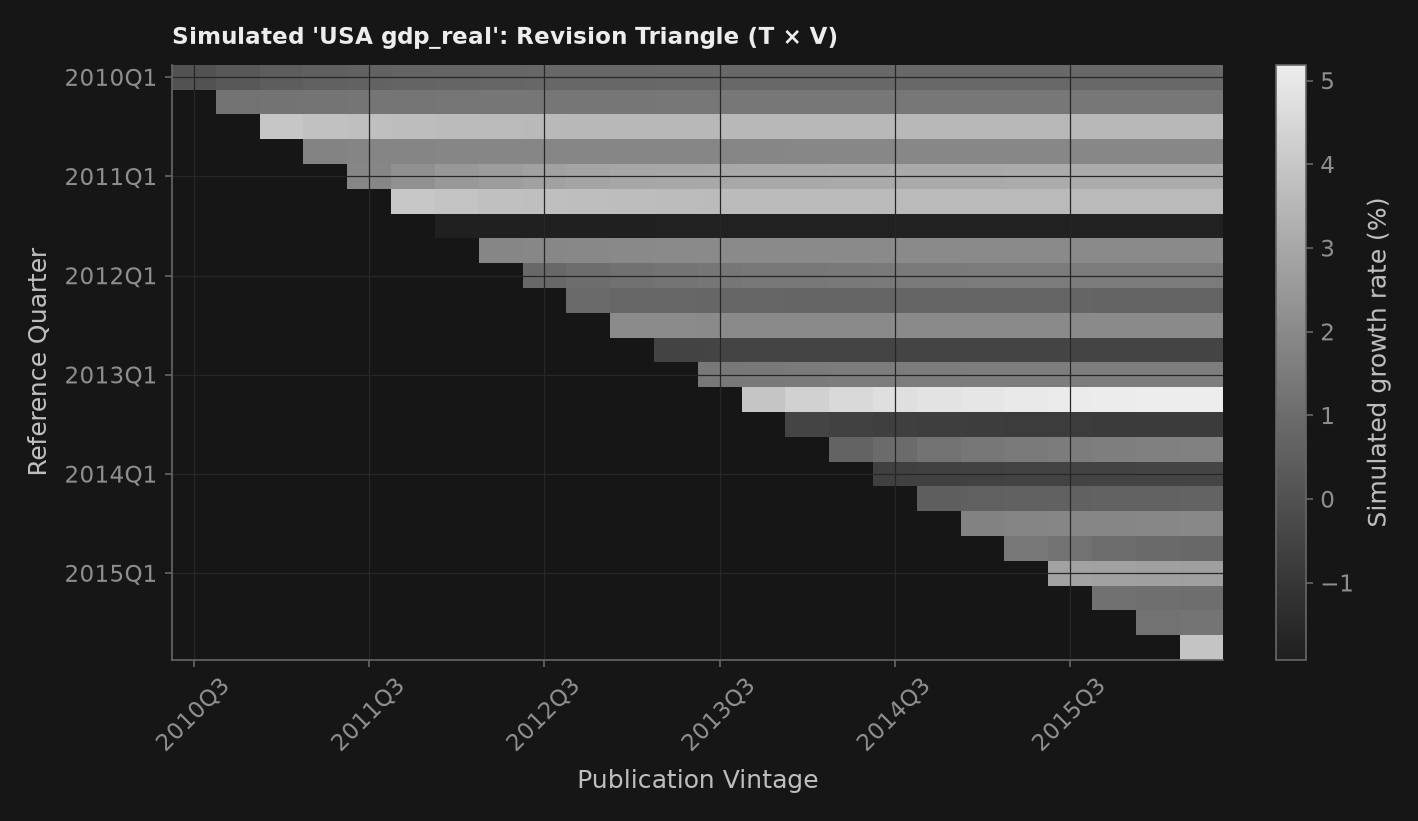

In [5]:
fig, ax = _nbstyle.figura(figsize=(9.2, 5.2))

im = ax.imshow(tri_usa.iloc[:24, :24].to_numpy(), cmap=_nbstyle.CMAP_SEQ, aspect="auto")
ax.set_title("Simulated 'USA gdp_real': Revision Triangle (T × V)", fontsize=11, fontweight="bold")
ax.set_xlabel("Publication Vintage", color=_nbstyle.TEXTO)
ax.set_ylabel("Reference Quarter", color=_nbstyle.TEXTO)

ax.set_xticks(range(0, 24, 4))
ax.set_xticklabels([f"{d.year}Q{d.quarter}" for d in tri_usa.columns[:24:4]], rotation=45)
ax.set_yticks(range(0, 24, 4))
ax.set_yticklabels([f"{d.year}Q{d.quarter}" for d in tri_usa.index[:24:4]])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Simulated growth rate (%)", color=_nbstyle.TEXTO)

## 4. First Release vs. Latest Estimate

Comparing the first release with the latest estimate shows the size and sign of the revisions:

$$ r_t = y_{T, t} - y_{0, t} $$

If revisions are non-zero on average ($\bar{r} \neq 0$), the first release is biased. If they are correlated with the business cycle, decisions based on unrevised data can be systematically wrong (Orphanides, 2001).

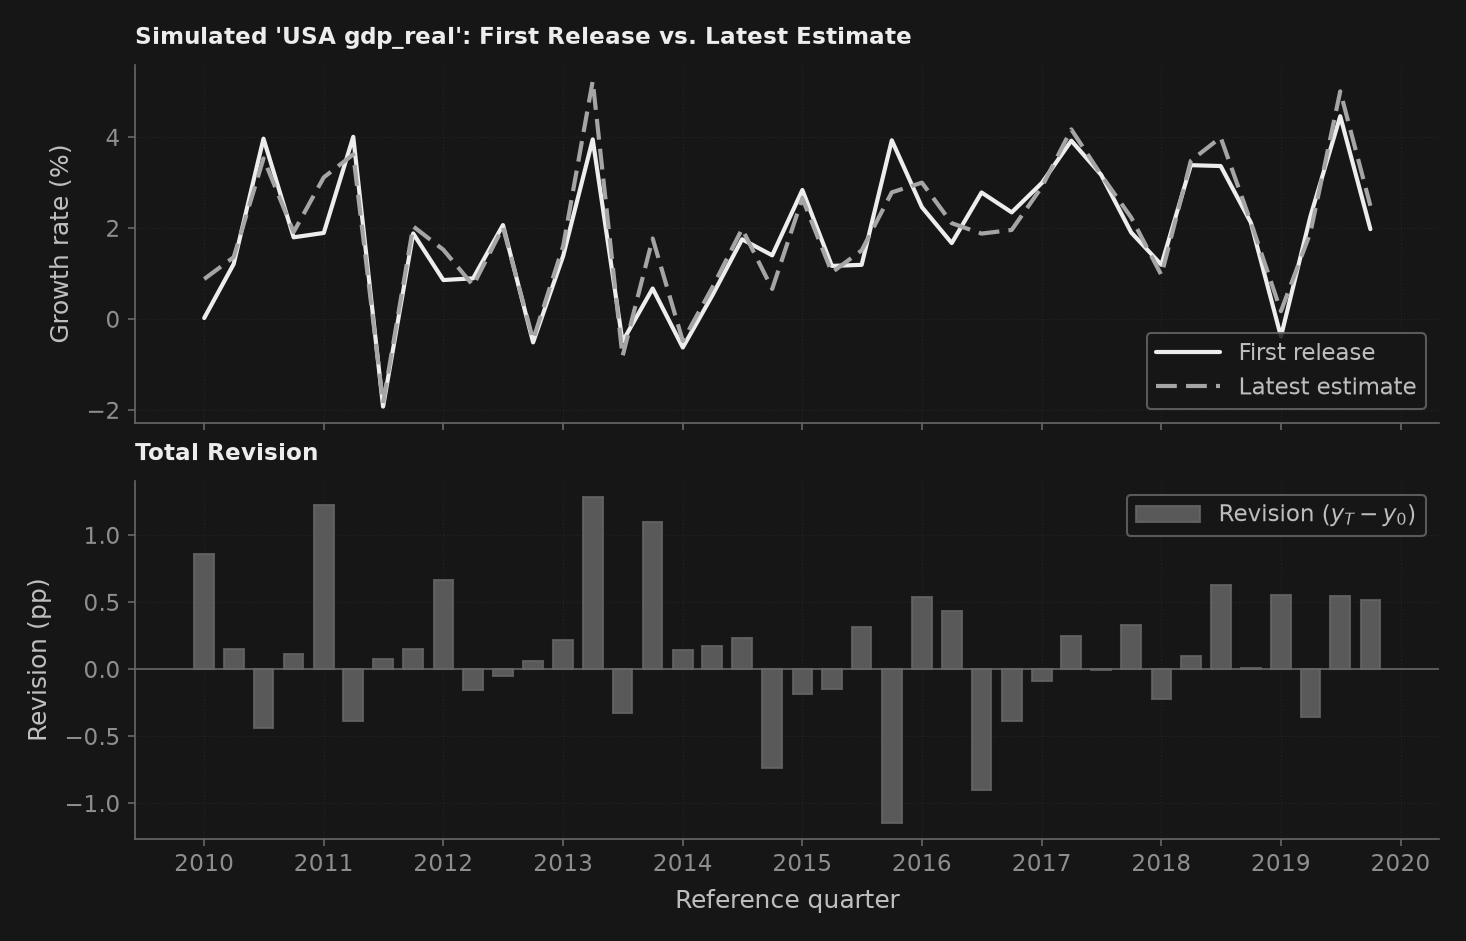

In [6]:
s_first = panel.first_release("USA", "gdp_real")
s_latest = panel.latest_release("USA", "gdp_real")

fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=(9.5, 6.0), sharex=True)

ax1.plot(s_first.index, s_first.values, **_nbstyle.S1, label="First release")
ax1.plot(s_latest.index, s_latest.values, **_nbstyle.S2, label="Latest estimate")
ax1.set_title("Simulated 'USA gdp_real': First Release vs. Latest Estimate", fontsize=11, fontweight="bold")
ax1.set_ylabel("Growth rate (%)", color=_nbstyle.TEXTO)
ax1.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax1.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

revision = s_latest - s_first
ax2.bar(revision.index, revision.values, color=_nbstyle.S3["color"], width=60, edgecolor=_nbstyle.SPINE, alpha=0.8, label="Revision ($y_T - y_0$)")
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="-")
ax2.set_title("Total Revision", fontsize=11, fontweight="bold")
ax2.set_xlabel("Reference quarter", color=_nbstyle.TEXTO)
ax2.set_ylabel("Revision (pp)", color=_nbstyle.TEXTO)
ax2.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax2.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

## 5. The Mankiw-Shapiro (1986) Test on a Known Noise Process

### The two hypotheses
1. **News ($H_{\text{news}}$).** The agency publishes its best forecast of the final figure given the information $\Omega_t$ it has:
   $$ y_{0, t} = \mathbb{E}[y_{T, t} \mid \Omega_t] \implies y_{T, t} = y_{0, t} + \nu_t, \quad \mathbb{E}[\nu_t \mid \Omega_t] = 0 $$
   The revision $r_t = \nu_t$ is unpredictable from the first release, so in $r_t = \alpha_0 + \beta_0 y_{0,t} + \varepsilon_t$ we have $\beta_0 = 0$. It is correlated with the final figure: $\beta_T = \text{Var}(\nu)/\text{Var}(y_T) > 0$.

2. **Noise ($H_{\text{noise}}$).** The agency observes the final figure with classical measurement error:
   $$ y_{0, t} = y_{T, t} + v_t, \quad \text{Cov}(y_{T, t}, v_t) = 0 $$
   The revision $r_t = -v_t$ is uncorrelated with the final figure, so $\beta_T = 0$. On the first release,
   $$ \beta_0 = \frac{\text{Cov}(-v_t, \, y_{T, t} + v_t)}{\text{Var}(y_{0, t})} = \frac{-\sigma_v^2}{\sigma_{y_T}^2 + \sigma_v^2}, $$
   which lies in $(-1, 0)$ and equals $-1$ only in the limit where the noise variance dominates. A slope of $-1$ is not the noise null.

In our simulation $\sigma_{y_T} = \sigma_* = 1.5$ and $\sigma_v = 0.6$, so the population slope is $\beta_0 = -0.36/2.61 \approx -0.14$ (the cell prints it). The noise null is therefore tested on the **final** release, $\beta_T = 0$, and the news null on the first, $\beta_0 = 0$.

`QNAVintagePanel.revision_stats` runs both regressions through `puremacro.vintages.mankiw_shapiro`, with heteroskedasticity-robust standard errors (Newey-West with `hac_lags`) and Student-$t$ $p$-values, and combines the two tests at 5% into one label:

| News leg ($\beta_0 = 0$) | Noise leg ($\beta_T = 0$) | Label |
|---|---|---|
| not rejected | rejected | "news" |
| rejected | not rejected | "noise" |
| rejected | rejected | "mixed" |
| not rejected | not rejected | "indeterminate" |

"Indeterminate" is a failure to reject both nulls: the sample cannot tell news from noise. It is not evidence for either. The dictionary also reports the noise share $\max(0, -\hat\beta_0)$, a magnitude to read next to the two $p$-values.

In [7]:
beta_pop = -sd_noise**2 / (sd_true**2 + sd_noise**2)
stats_usa = panel.revision_stats("USA", "gdp_real")

print("==================================================================")
print("  MANKIW & SHAPIRO (1986) TEST, simulated 'USA gdp_real'")
print("==================================================================")
print(f"Known process:            pure noise, population slope on y_0 = {beta_pop:.4f}")
print(f"Sample size (N):          {stats_usa['n_obs']}")
print(f"Mean revision:            {stats_usa['mean_revision']:.4f} (p = {stats_usa['p_mean_revision']:.4f})")
print(f"Revision std. dev.:       {stats_usa['std_revision']:.4f}")
print("------------------------------------------------------------------")
print(f"News leg,  r on y_0:      beta_0 = {stats_usa['mankiw_shapiro_beta']:.4f} (s.e. {stats_usa['mankiw_shapiro_se']:.4f}, p = {stats_usa['mankiw_shapiro_pvalue']:.4f})")
print(f"Noise leg, r on y_T:      beta_T = {stats_usa['mankiw_shapiro_beta_final']:.4f} (s.e. {stats_usa['mankiw_shapiro_se_final']:.4f}, p = {stats_usa['mankiw_shapiro_pvalue_final']:.4f})")
print(f"Noise share:              {stats_usa['noise_share']:.4f} (population {-beta_pop:.4f})")
print(f"Label:                    {stats_usa['hypothesis']}")
print("==================================================================")

# Internal check: revision_stats runs the same regressions as mankiw_shapiro
ms_usa = mankiw_shapiro(s_first, s_latest)
assert abs(ms_usa.beta_on_preliminary - stats_usa["mankiw_shapiro_beta"]) < 1e-10
assert abs(ms_usa.p_beta_on_final - stats_usa["mankiw_shapiro_pvalue_final"]) < 1e-10

  MANKIW & SHAPIRO (1986) TEST, simulated 'USA gdp_real'
Known process:            pure noise, population slope on y_0 = -0.1379
Sample size (N):          40
Mean revision:            0.1286 (p = 0.1232)
Revision std. dev.:       0.5226
------------------------------------------------------------------
News leg,  r on y_0:      beta_0 = -0.0477 (s.e. 0.0583, p = 0.4187)
Noise leg, r on y_T:      beta_T = 0.0735 (s.e. 0.0498, p = 0.1487)
Noise share:              0.0477 (population 0.1379)
Label:                    indeterminate


In [8]:
# Cross-country comparison: both legs and the label, from revision_stats
results_all = []
for c in countries:
    for v in variables:
        st = panel.revision_stats(c, v)
        results_all.append({
            "Country": c,
            "Variable": v,
            "N": st["n_obs"],
            "Mean rev.": round(st["mean_revision"], 4),
            "beta_0": round(st["mankiw_shapiro_beta"], 4),
            "p(beta_0=0)": round(st["mankiw_shapiro_pvalue"], 4),
            "beta_T": round(st["mankiw_shapiro_beta_final"], 4),
            "p(beta_T=0)": round(st["mankiw_shapiro_pvalue_final"], 4),
            "Label": st["hypothesis"],
        })

df_test_summary = pd.DataFrame(results_all)
print("Mankiw-Shapiro test on 8 simulated series (known process: pure noise)")
print(df_test_summary.to_string(index=False))
print(f"\nPopulation slopes: beta_0 = {beta_pop:.4f}, beta_T = 0")
print(f"Mean of the 8 estimates: beta_0 = {df_test_summary['beta_0'].mean():.4f}, beta_T = {df_test_summary['beta_T'].mean():.4f}")
print(f"Labels: {df_test_summary['Label'].value_counts().to_dict()}")

assert (df_test_summary["beta_0"] < 0).all(), "under classical noise every slope on y_0 should be negative here"
assert abs(df_test_summary["beta_0"].mean() - beta_pop) < 0.05, "the average slope should be near the population slope"
assert abs(df_test_summary["beta_T"].mean()) < 0.05, "the average slope on y_T should be near zero"
assert (df_test_summary["beta_0"] > -1).all(), "a slope of -1 is not what classical noise produces"

Mankiw-Shapiro test on 8 simulated series (known process: pure noise)
Country  Variable  N  Mean rev.  beta_0  p(beta_0=0)  beta_T  p(beta_T=0)         Label
    USA  gdp_real 40     0.1286 -0.0477       0.4187  0.0735       0.1487 indeterminate
    USA gfcf_real 40     0.1689 -0.1569       0.0003 -0.0462       0.4836         noise
    DEU  gdp_real 40    -0.0385 -0.0962       0.0586  0.0870       0.1811 indeterminate
    DEU gfcf_real 40     0.0791 -0.2431       0.0000 -0.0654       0.3868         noise
    GBR  gdp_real 40    -0.0440 -0.2127       0.0000 -0.1638       0.0068         mixed
    GBR gfcf_real 40     0.0553 -0.1085       0.1456  0.1406       0.0487          news
    MEX  gdp_real 40     0.0574 -0.1187       0.0031 -0.0228       0.5976         noise
    MEX gfcf_real 40    -0.0693 -0.1933       0.0005 -0.0897       0.1746         noise

Population slopes: beta_0 = -0.1379, beta_T = 0
Mean of the 8 estimates: beta_0 = -0.1471, beta_T = -0.0108
Labels: {'noise': 4, 'indeter

## 6. The Mankiw-Shapiro Scatter

Plotting the first release $y_{0, t}$ against the revision $r_t = y_{T, t} - y_{0, t}$ shows the news regression directly:

- A horizontal line ($\beta_0 = 0$) is what the **news** hypothesis predicts.
- Under classical **noise**, the line slopes down with the variance ratio $\beta_0 = -\sigma_v^2 / (\sigma_{y_T}^2 + \sigma_v^2)$, here about $-0.14$, not $-1$.
- The OLS line is the estimate from this sample of 40 quarters.

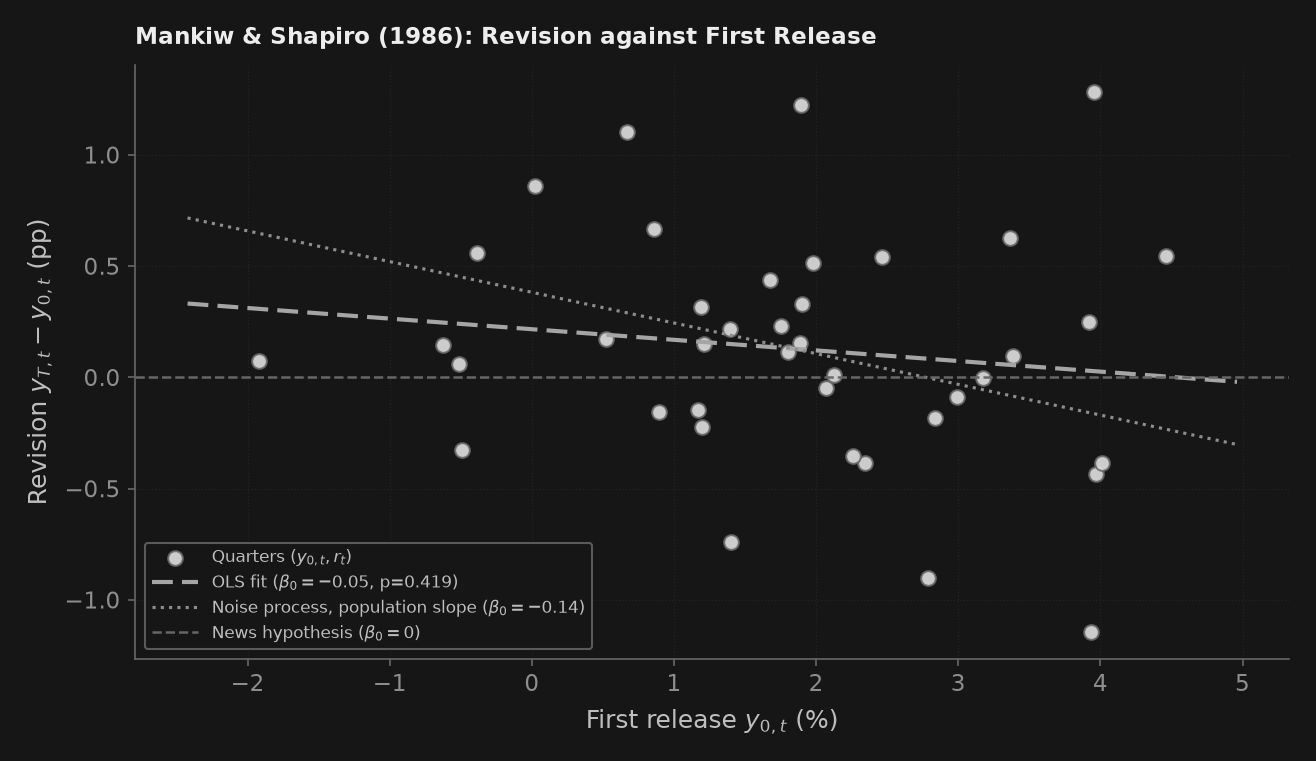

In [9]:
fig, ax = _nbstyle.figura(figsize=(8.5, 4.8))

x_vals = s_first.values
y_vals = (s_latest - s_first).values
ax.scatter(x_vals, y_vals, color=_nbstyle.S1["color"], edgecolors=_nbstyle.SPINE, s=50, alpha=0.85, label="Quarters ($y_{0,t}, r_t$)")

x_grid = np.linspace(x_vals.min() - 0.5, x_vals.max() + 0.5, 100)
y_fit = stats_usa["mankiw_shapiro_alpha"] + stats_usa["mankiw_shapiro_beta"] * x_grid
ax.plot(x_grid, y_fit, **_nbstyle.S2, label=f"OLS fit ($\\beta_0={stats_usa['mankiw_shapiro_beta']:.2f}$, p={stats_usa['mankiw_shapiro_pvalue']:.3f})")

# Population slope of the known noise process, drawn through the sample means
y_noise = y_vals.mean() + beta_pop * (x_grid - x_vals.mean())
ax.plot(x_grid, y_noise, color=_nbstyle.NOTA, lw=1.5, linestyle=":", label=f"Noise process, population slope ($\\beta_0={beta_pop:.2f}$)")

ax.axhline(0, color=_nbstyle.SPINE, lw=1.2, linestyle="--", label="News hypothesis ($\\beta_0=0$)")

ax.set_title("Mankiw & Shapiro (1986): Revision against First Release", fontsize=11, fontweight="bold")
ax.set_xlabel("First release $y_{0,t}$ (%)", color=_nbstyle.TEXTO)
ax.set_ylabel("Revision $y_{T,t} - y_{0,t}$ (pp)", color=_nbstyle.TEXTO)
ax.legend(loc="lower left", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE, fontsize=8)
ax.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

## 7. Point-in-Time Data Sets (`.as_of()`)

Pseudo-out-of-sample forecasting and historical decompositions must use only what was published at the time; using revised data brings later information into the past (look-ahead bias).

`panel.as_of(date)` rebuilds the data set available on a publication date. For a vintage $V^*$ it keeps, for every series and reference quarter, the latest estimate published on or before $V^*$:

$$ \mathcal{I}_{V^*} = \left\{ y_{v, t} \;\Big|\; v \le V^* \text{ and } v = \max_{u \le V^*} u \right\} $$

In [10]:
df_2018 = panel.as_of("2018-04-01")
print("Point-in-time panel as of 2018-04-01 (first 10 rows):")
print(df_2018.head(10).round(3).to_string())

df_2022 = panel.as_of("2022-01-01")
print(f"\nObservations available in the 2018 snapshot: {len(df_2018)}")
print(f"Observations available in the 2022 snapshot: {len(df_2022)}")

Point-in-time panel as of 2018-04-01 (first 10 rows):
                    gdp_real  gfcf_real
country date                           
DEU     2010-01-01     3.513      5.579
        2010-04-01     3.818      1.556
        2010-07-01     4.513      3.497
        2010-10-01     1.570      1.342
        2011-01-01     2.529      1.250
        2011-04-01     0.174      1.466
        2011-07-01     3.139      1.372
        2011-10-01     2.483      4.080
        2012-01-01     0.918      3.051
        2012-04-01     6.051      3.832

Observations available in the 2018 snapshot: 128
Observations available in the 2022 snapshot: 160


## Read the output

**Read the output.** The panel is pure noise by construction, so every verdict can be graded against the truth.

1. **The population slope is small.** With $\sigma_* = 1.5$ and $\sigma_v = 0.6$ the slope of the revision on the first release is $-0.1379$, not $-1$. It is a closed form derived by hand for the known process, independent of puremacro. The eight estimated slopes are all negative and average $-0.1471$; the slopes on the latest estimate average $-0.0108$, close to their population value of zero.
2. **One series, one sample.** For the simulated 'USA gdp_real' the slope on the first release is $-0.0477$ (s.e. $0.0583$, $p = 0.4187$), so this sample of 40 quarters cannot reject news although the truth is noise. The noise leg does not reject either ($p = 0.1487$), and `revision_stats` labels the series "indeterminate": the honest answer, since neither null is rejected. Its estimated noise share, $0.0477$, is a third of the population value $0.1379$. The same slopes come out of `mankiw_shapiro` directly (an internal check).
3. **Eight series.** `revision_stats` finds the right answer ("noise") for 4 of the 8 series and cannot decide for 2 ('USA gdp_real' and 'DEU gdp_real'). It rejects the true noise null for both 'GBR' series ($p = 0.0068$ and $p = 0.0487$), which makes one "mixed" and one "news": at the 5% level such false rejections are expected in about one series in twenty, and two in eight is bad luck in this draw. With a noise share of only $0.1379$ and 40 quarters, the test has limited power, and a label for one series is weak evidence. The mean revision of 'USA gdp_real' ($0.1286$, $p = 0.1232$) is not significant, as it should not be: this process has no bias.
4. **No slope near $-1$.** Every slope on the first release lies between $-0.2431$ and $-0.0477$. A rule that waited for a slope near $-1$ before calling a series noise would call none of these eight series noise; under classical noise such a slope needs the error to account for most of the variance of the first release (prompt 2).
5. **Information sets.** The snapshot of 2018-04-01 holds 128 observations against 160 in 2022: an analysis dated April 2018 must use the smaller, unrevised panel.

## Your turn

Change how noisy the first release is, or switch the process from noise to news, and **predict both slopes before running**: the slope of the revision on the first release ($\beta_0$) and on the latest estimate ($\beta_T$). The cell rebuilds the panel with the same random draws, estimates both slopes for all eight series, and checks that their averages are within three standard errors of your predictions. The prediction written in the cell is the population formula; replace it with your own. Setting $\beta_0 = -1$ for the noise process fails the check.

In [11]:
# Your turn: predict both Mankiw-Shapiro slopes, then let the simulation grade you
sd_v_turn = 0.6        # ← change this: s.d. of the first-release error (noise) or of the news, 0.3 to 3.0
dgp_turn = "noise"     # ← change this: "noise" (y_0 = y* + v) or "news" (y_0 = y*, revisions add v)
assert 0.3 <= sd_v_turn <= 3.0 and dgp_turn in ("noise", "news")

share = sd_v_turn**2 / (sd_true**2 + sd_v_turn**2)
my_beta_0 = -share if dgp_turn == "noise" else 0.0   # slope of r on y_0: replace with your prediction
my_beta_T = 0.0 if dgp_turn == "noise" else share    # slope of r on y_T: replace with your prediction

panel_turn = simulate_vintages(sd_v_turn, dgp_turn)
b0, bT, labels = [], [], []
for c in countries:
    for v in variables:
        st = panel_turn.revision_stats(c, v)
        b0.append(st["mankiw_shapiro_beta"])
        bT.append(st["mankiw_shapiro_beta_final"])
        labels.append(st["hypothesis"])
b0, bT = np.array(b0), np.array(bT)
se0, seT = b0.std(ddof=1) / np.sqrt(len(b0)), bT.std(ddof=1) / np.sqrt(len(bT))

print(f"Process: {dgp_turn}, sd_v = {sd_v_turn}, noise share of Var(y_0 or y_T) = {share:.4f}")
print(f"  beta_0: mean {b0.mean():+.4f} (s.e. {se0:.4f}), your prediction {my_beta_0:+.4f}")
print(f"  beta_T: mean {bT.mean():+.4f} (s.e. {seT:.4f}), your prediction {my_beta_T:+.4f}")
print(f"  labels: {pd.Series(labels).value_counts().to_dict()}")

assert abs(b0.mean() - my_beta_0) < 3 * se0 + 0.01, "slope on the first release is far from your prediction"
assert abs(bT.mean() - my_beta_T) < 3 * seT + 0.01, "slope on the latest estimate is far from your prediction"

Process: noise, sd_v = 0.6, noise share of Var(y_0 or y_T) = 0.1379
  beta_0: mean -0.1471 (s.e. 0.0233), your prediction -0.1379
  beta_T: mean -0.0109 (s.e. 0.0362), your prediction +0.0000
  labels: {'noise': 4, 'indeterminate': 2, 'mixed': 1, 'news': 1}


**Prompts.**
1. *Basic.* With the default settings, derive $\beta_0 = \text{Cov}(-v, y^* + v)/\text{Var}(y^* + v)$ as a number before running. Why is it nowhere near $-1$ although the first release is pure noise? You can ignore the small error left in the latest vintages.
2. *Intermediate.* Suppose a rule calls a series "noise" only when $|\hat\beta_0 + 1| < 0.3$. Invert the slope formula to find the noise s.d. that makes $\beta_0 = -0.8$, set `sd_v_turn` to it and rerun. How noisy must the first release be before that rule could say "noise", and how many of the eight series would it call noise at the default setting? What do the labels of `revision_stats` say at both settings, and why does the two-leg test not need to know the noise share?
3. *Stretch.* Set `dgp_turn = "news"`. Predict both slopes, then explain why comparing the two regressions tells news from noise when the single regression on $y_0$ with a $-1$ threshold cannot. With 40 quarters per series, how many of the eight labels are wrong under each process, and what kind of error is each (a false rejection or a failure to reject)? Rerun with `panel_turn.revision_stats(c, v, hac_lags="auto")` inside the loop: do the Newey-West errors change any label?

## How comprehensive is this?

- `puremacro.vintages`: `mankiw_shapiro` (both legs, with HAC standard errors through `hac_lags`), `revision_test` on long vintage panels, and revision triangles.
- `puremacro.fetch.QNAVintagePanel` and `get_qna_vintage_catalog`: point-in-time slicing, first and latest releases, `revision_stats` (both Mankiw-Shapiro legs and a news/noise/mixed/indeterminate label, through `mankiw_shapiro`), and the catalogue used by the real-time fetchers (which download data and are not called here).
- `puremacro.fetch.realtime.VintagePanel`: the same operations for Latin American central-bank panels, including `news_or_noise` (notebooks 58 and 59); notebook 58 runs the two-leg test on a panel with only a few revision pairs, and notebook 48 applies the corrected noise null in a nowcasting example.